# Modelado — Spotify Growth ML

## Configuración General

### 📚 Importación de librerías

In [2]:
# Librerias
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

plt.style.use("default")
sns.set_palette("deep")
pd.set_option("display.max_columns", None)


#### ⏫ Importacion de datos


In [3]:
BASE_DIR = Path().resolve().parent if Path().resolve().name == "notebooks" else Path().resolve()
PROCESSED_DIR = BASE_DIR / "data" / "processed"
REPORTS_DIR = BASE_DIR / "reports" / "03_modeling" / "model_performance"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

processed_files = sorted(PROCESSED_DIR.glob("spotify_model_ready_*.parquet"), key=os.path.getmtime)
if not processed_files:
    raise FileNotFoundError("No se encontraron archivos procesados en data/processed")

latest_processed_path = processed_files[-1]
print("Using processed file:", latest_processed_path)

df = pd.read_parquet(latest_processed_path)
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head(3)


Using processed file: /Users/nguisande/Library/CloudStorage/OneDrive-Personal/Nicolas/Personal/Cursos/Carrera - Data Scientist - Coder House/Curso - Data Science II/Proyecto Final/spotify-growth-ml/data/processed/spotify_model_ready_20260301_005928.parquet
Shape: (66074, 13)
Columns: ['track_id', 'track_popularity', 'artist_avg_popularity', 'playlist_avg_popularity', 'playlist_popularity_std', 'artist_popularity_std', 'years_since_release', 'album_release_year', 'playlist_track_count', 'artist_track_count', 'artist_avg_duration', 'playlist_avg_duration', 'popular_high']


,track_id,track_popularity,artist_avg_popularity,playlist_avg_popularity,playlist_popularity_std,artist_popularity_std,years_since_release,album_release_year,playlist_track_count,artist_track_count,artist_avg_duration,playlist_avg_duration,popular_high
0,7Dev2VJdJKwIIUdj3lcQl9,73,53.585714,53.695279,19.799138,21.772535,0.062971,2026.0,233.0,70,3.651259,2.59103,1
1,09CnYHiZ5jGT1wr1TXJ9Zt,82,26.609756,53.695279,19.799138,25.557658,2.247775,2023.0,233.0,41,3.695037,2.59103,1
2,2qlqMa0e422LZyGw1J5for,69,26.609756,53.695279,19.799138,25.557658,0.963723,2025.0,233.0,41,3.695037,2.59103,1


#### 🛡️ Validación de contrato de entrada


In [4]:
required_cols = {
    "track_id", "track_popularity", "popular_high",
    "artist_avg_popularity", "playlist_avg_popularity", "playlist_popularity_std",
    "artist_popularity_std", "years_since_release", "album_release_year",
    "playlist_track_count", "artist_track_count", "artist_avg_duration", "playlist_avg_duration"
}

missing_cols = sorted(required_cols - set(df.columns))
if missing_cols:
    raise KeyError(f"Faltan columnas requeridas: {missing_cols}")

nulls_total = int(df.isna().sum().sum())
if nulls_total != 0:
    raise ValueError(f"El dataset procesado contiene nulos ({nulls_total})")

target_counts = df["popular_high"].value_counts().sort_index()
target_pct = (df["popular_high"].value_counts(normalize=True).sort_index() * 100).round(2)
print("Target counts:", target_counts.to_dict())
print("Target pct:", target_pct.to_dict())


Target counts: {0: 45479, 1: 20595}
Target pct: {0: 68.83, 1: 31.17}


### ✂️ Split train/test


In [5]:
X = df.drop(columns=["track_id", "track_popularity", "popular_high"])
y = df["popular_high"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42,
)

print("X shape:", X.shape)
print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("y_train distribution:", y_train.value_counts(normalize=True).round(4).to_dict())


X shape: (66074, 10)
X_train: (52859, 10) | X_test: (13215, 10)
y_train distribution: {0: 0.6883, 1: 0.3117}


---

## MÓDULO 1: Clasificación Supervisada

**Target:** `popular_high` (binario: 1 si popularidad ≥ P70, 0 en caso contrario)

**Etapas:**
1. Modelos baseline (5 clasificadores)
2. Validación cruzada StratifiedKFold(5)
3. Ensambles adicionales (AdaBoost, Bagging, ExtraTrees)
4. Optimización de hiperparámetros (RandomizedSearchCV)
5. Comparativa completa + resumen ejecutivo + exportación

### 1.1 Definición de modelos baseline

In [6]:
model_configs = {
    "Dummy": {
        "estimator": DummyClassifier(strategy="stratified", random_state=42),
        "scale": False,
    },
    "LogisticRegression": {
        "estimator": LogisticRegression(max_iter=2000, random_state=42),
        "scale": True,
    },
    "RandomForest": {
        "estimator": RandomForestClassifier(
            n_estimators=400,
            random_state=42,
            n_jobs=-1,
            class_weight="balanced_subsample",
        ),
        "scale": False,
    },
    "GradientBoosting": {
        "estimator": GradientBoostingClassifier(random_state=42),
        "scale": False,
    },
    "LinearSVM": {
        "estimator": SGDClassifier(loss="log_loss", max_iter=2000, random_state=42),
        "scale": True,
    },
}


def build_model(config):
    if config["scale"]:
        return Pipeline([
            ("scaler", StandardScaler()),
            ("model", config["estimator"]),
        ])
    return config["estimator"]

models = {name: build_model(cfg) for name, cfg in model_configs.items()}
print("Modelos definidos:", list(models.keys()))


Modelos definidos: ['Dummy', 'LogisticRegression', 'RandomForest', 'GradientBoosting', 'LinearSVM']


### 1.2 Evaluación homogénea por modelo

In [7]:
def get_probability_scores(model, X_data):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X_data)[:, 1]

    if hasattr(model, "decision_function"):
        decision = model.decision_function(X_data)
        # Conversión sigmoide para homogeneizar umbral y reportes
        return 1.0 / (1.0 + np.exp(-decision))

    raise AttributeError("El modelo no soporta predict_proba ni decision_function")


def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)

    y_score = get_probability_scores(model, X_test)
    y_pred = (y_score >= 0.5).astype(int)

    metrics = {
        "model": name,
        "roc_auc": roc_auc_score(y_test, y_score),
        "pr_auc": average_precision_score(y_test, y_score),
        "f1": f1_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "accuracy": accuracy_score(y_test, y_pred),
    }

    return metrics, y_score, y_pred

results_rows = []
predictions_store = {}

for name, model in models.items():
    metrics, y_score, y_pred = evaluate_model(name, model, X_train, y_train, X_test, y_test)
    results_rows.append(metrics)
    predictions_store[name] = {
        "model": model,
        "y_score": y_score,
        "y_pred": y_pred,
    }

results_df = pd.DataFrame(results_rows).sort_values("roc_auc", ascending=False).reset_index(drop=True)
results_df


,model,roc_auc,pr_auc,f1,precision,recall,accuracy
0,RandomForest,0.943739,0.881421,0.791927,0.783829,0.800194,0.868937
1,GradientBoosting,0.943498,0.880951,0.794560,0.794753,0.794368,0.871964
2,LogisticRegression,0.919163,0.819383,0.749278,0.775871,0.724448,0.848884
3,LinearSVM,0.917879,0.809512,0.755204,0.757324,0.753095,0.847824
4,Dummy,0.496132,0.310061,0.302628,0.306239,0.299102,0.570337


### 1.3 Resultados comparativos — baseline

In [8]:
results_df_rounded = results_df.copy()
for col in ["roc_auc", "pr_auc", "f1", "precision", "recall", "accuracy"]:
    results_df_rounded[col] = results_df_rounded[col].round(4)

results_df_rounded


,model,roc_auc,pr_auc,f1,precision,recall,accuracy
0,RandomForest,0.9437,0.8814,0.7919,0.7838,0.8002,0.8689
1,GradientBoosting,0.9435,0.8810,0.7946,0.7948,0.7944,0.8720
2,LogisticRegression,0.9192,0.8194,0.7493,0.7759,0.7244,0.8489
3,LinearSVM,0.9179,0.8095,0.7552,0.7573,0.7531,0.8478
4,Dummy,0.4961,0.3101,0.3026,0.3062,0.2991,0.5703


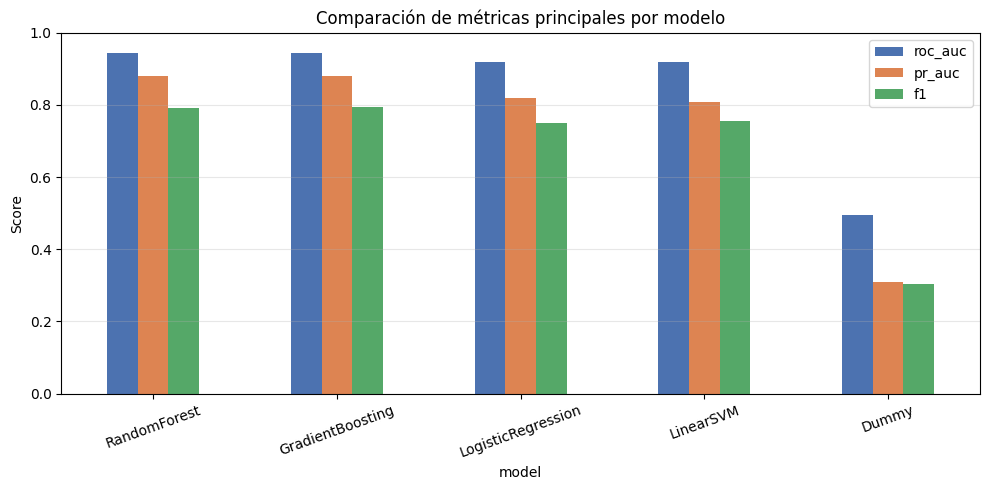

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
plot_df = results_df.set_index("model")[["roc_auc", "pr_auc", "f1"]]
plot_df.plot(kind="bar", ax=ax)
ax.set_title("Comparación de métricas principales por modelo")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


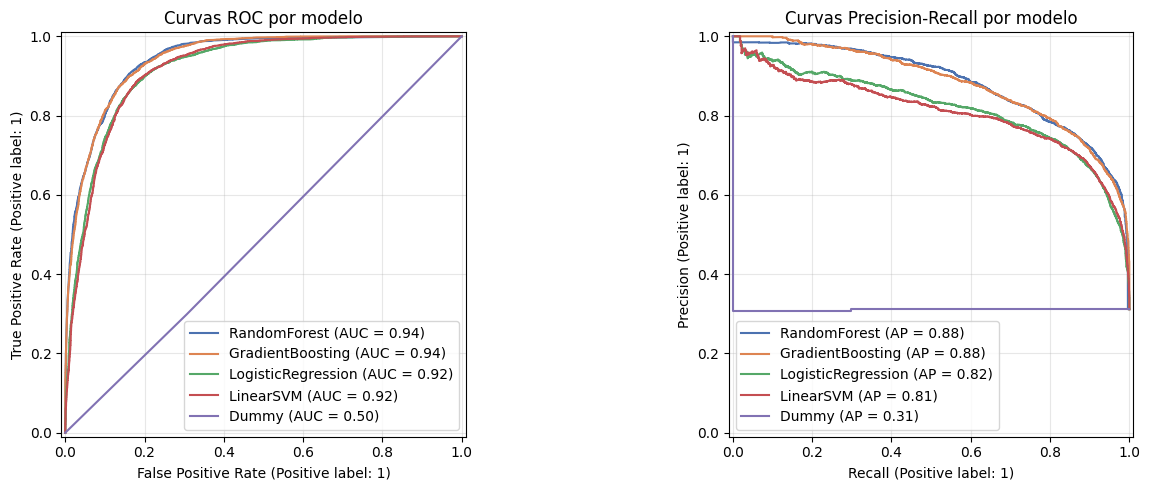

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for _, row in results_df.iterrows():
    name = row["model"]
    y_score = predictions_store[name]["y_score"]
    RocCurveDisplay.from_predictions(y_test, y_score, name=name, ax=axes[0])
    PrecisionRecallDisplay.from_predictions(y_test, y_score, name=name, ax=axes[1])

axes[0].set_title("Curvas ROC por modelo")
axes[1].set_title("Curvas Precision-Recall por modelo")
axes[0].grid(alpha=0.3)
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()


### 1.4 Análisis del mejor modelo baseline

In [11]:
best_model_name = results_df.iloc[0]["model"]
best_model_obj = predictions_store[best_model_name]["model"]
best_y_score = predictions_store[best_model_name]["y_score"]
best_y_pred = predictions_store[best_model_name]["y_pred"]

print("Best model:", best_model_name)
print("\nClassification report:\n")
print(classification_report(y_test, best_y_pred, digits=4))

cm = confusion_matrix(y_test, best_y_pred)
cm_df = pd.DataFrame(cm, index=["Actual_0", "Actual_1"], columns=["Pred_0", "Pred_1"])
print("Confusion matrix:")
cm_df


Best model: RandomForest

Classification report:

              precision    recall  f1-score   support

           0     0.9087    0.9001    0.9043      9096
           1     0.7838    0.8002    0.7919      4119

    accuracy                         0.8689     13215
   macro avg     0.8462    0.8501    0.8481     13215
weighted avg     0.8697    0.8689    0.8693     13215

Confusion matrix:


,Pred_0,Pred_1
Actual_0,8187,909
Actual_1,823,3296


In [12]:
def extract_feature_importance(model, feature_names):
    estimator = model.named_steps["model"] if isinstance(model, Pipeline) else model

    if hasattr(estimator, "coef_"):
        values = np.abs(estimator.coef_).ravel()
        return pd.DataFrame({"feature": feature_names, "importance": values}).sort_values("importance", ascending=False)

    if hasattr(estimator, "feature_importances_"):
        values = estimator.feature_importances_
        return pd.DataFrame({"feature": feature_names, "importance": values}).sort_values("importance", ascending=False)

    return pd.DataFrame(columns=["feature", "importance"])

feature_importance_df = extract_feature_importance(best_model_obj, X.columns.tolist())
feature_importance_df.head(10)


,feature,importance
0,artist_avg_popularity,0.389771
1,playlist_avg_popularity,0.136547
3,artist_popularity_std,0.105387
4,years_since_release,0.093860
2,playlist_popularity_std,0.063530
7,artist_track_count,0.051443
5,album_release_year,0.047589
8,artist_avg_duration,0.042828
6,playlist_track_count,0.036045
9,playlist_avg_duration,0.032999


### 1.5 Validación Cruzada, Ensambles y Optimización de Hiperparámetros

In [14]:
from sklearn.model_selection import StratifiedKFold, KFold, cross_val_score, RandomizedSearchCV
from sklearn.ensemble import AdaBoostClassifier, BaggingClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from scipy.stats import randint, uniform

# ---- Validación cruzada: StratifiedKFold(5) sobre todos los modelos baseline ----
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Validación Cruzada (StratifiedKFold 5) — Clasificación baseline:")
clf_cv_rows = []
for name, model in models.items():
    cv_scores = cross_val_score(model, X, y, cv=skf, scoring="roc_auc", n_jobs=-1)
    clf_cv_rows.append({
        "model": name,
        "cv_roc_auc_mean": cv_scores.mean(),
        "cv_roc_auc_std": cv_scores.std(),
    })

clf_cv_df = (pd.DataFrame(clf_cv_rows)
             .sort_values("cv_roc_auc_mean", ascending=False)
             .reset_index(drop=True))
print(clf_cv_df.round(4).to_string(index=False))

# ---- Modelos de ensamble adicionales ----
ensemble_models_clf = {
    "AdaBoost":           AdaBoostClassifier(n_estimators=100, random_state=42),
    "BaggingClassifier":  BaggingClassifier(
                              estimator=DecisionTreeClassifier(max_depth=5),
                              n_estimators=50, random_state=42, n_jobs=-1),
    "ExtraTrees":         ExtraTreesClassifier(n_estimators=200, random_state=42,
                                               n_jobs=-1, class_weight="balanced"),
}

print("\nEvaluando ensambles adicionales (AdaBoost, Bagging, ExtraTrees)...")
ensemble_clf_rows = []
for name, model in ensemble_models_clf.items():
    metrics, y_score_e, y_pred_e = evaluate_model(name, model, X_train, y_train, X_test, y_test)
    cv_scores_e = cross_val_score(model, X, y, cv=skf, scoring="roc_auc", n_jobs=-1)
    metrics["cv_roc_auc_mean"] = cv_scores_e.mean()
    metrics["cv_roc_auc_std"] = cv_scores_e.std()
    ensemble_clf_rows.append(metrics)
    predictions_store[name] = {"model": model, "y_score": y_score_e, "y_pred": y_pred_e}

ensemble_clf_df = (pd.DataFrame(ensemble_clf_rows)
                   .sort_values("roc_auc", ascending=False)
                   .reset_index(drop=True))
print("\nEnsambles — Test Set + CV ROC-AUC:")
print(ensemble_clf_df[["model", "roc_auc", "pr_auc", "f1", "cv_roc_auc_mean", "cv_roc_auc_std"]].round(4).to_string(index=False))

Validación Cruzada (StratifiedKFold 5) — Clasificación baseline:
             model  cv_roc_auc_mean  cv_roc_auc_std
  GradientBoosting           0.9434          0.0026
      RandomForest           0.9432          0.0020
LogisticRegression           0.9200          0.0024
         LinearSVM           0.9193          0.0025
             Dummy           0.4990          0.0032

Evaluando ensambles adicionales (AdaBoost, Bagging, ExtraTrees)...

Ensambles — Test Set + CV ROC-AUC:
            model  roc_auc  pr_auc     f1  cv_roc_auc_mean  cv_roc_auc_std
BaggingClassifier   0.9369  0.8703 0.7770           0.9370          0.0026
         AdaBoost   0.9232  0.8263 0.7453           0.9263          0.0022
       ExtraTrees   0.9193  0.8223 0.7886           0.9206          0.0032


In [15]:
# ---- Optimización de hiperparámetros (RandomizedSearchCV) ----
print("RandomizedSearchCV para RandomForest (tarda ~2-3 min)...")
param_dist_rf = {
    "n_estimators": randint(100, 500),
    "max_depth": [None, 10, 15, 20, 30],
    "min_samples_split": randint(2, 20),
    "max_features": ["sqrt", "log2", 0.3, 0.5],
    "class_weight": ["balanced", "balanced_subsample"],
}
rscv_rf = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=param_dist_rf,
    n_iter=20, cv=skf, scoring="roc_auc", random_state=42, n_jobs=-1,
)
rscv_rf.fit(X_train, y_train)
print(f"  Mejores params RF: {rscv_rf.best_params_}")
print(f"  Mejor CV ROC-AUC RF: {rscv_rf.best_score_:.4f}")

print("\nRandomizedSearchCV para GradientBoosting (tarda ~3-5 min)...")
param_dist_gb = {
    "n_estimators": randint(100, 400),
    "learning_rate": uniform(0.01, 0.2),
    "max_depth": randint(3, 8),
    "subsample": uniform(0.6, 0.4),
    "min_samples_split": randint(2, 20),
}
rscv_gb = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_distributions=param_dist_gb,
    n_iter=15, cv=skf, scoring="roc_auc", random_state=42,
)
rscv_gb.fit(X_train, y_train)
print(f"  Mejores params GB: {rscv_gb.best_params_}")
print(f"  Mejor CV ROC-AUC GB: {rscv_gb.best_score_:.4f}")

# Evaluar modelos tuneados en test set
tuned_clf_rows = []
for name, estimator in [("RandomForest_Tuned", rscv_rf.best_estimator_),
                         ("GradientBoosting_Tuned", rscv_gb.best_estimator_)]:
    metrics, y_score_t, y_pred_t = evaluate_model(
        name, estimator, X_train, y_train, X_test, y_test
    )
    tuned_clf_rows.append(metrics)
    predictions_store[name] = {"model": estimator, "y_score": y_score_t, "y_pred": y_pred_t}

clf_tuned_df = pd.DataFrame(tuned_clf_rows).sort_values("roc_auc", ascending=False).reset_index(drop=True)

# Tabla comparativa final: baseline + ensambles + tuneados
comparison_all_clf = (
    pd.concat([
        results_df[["model", "roc_auc", "pr_auc", "f1", "accuracy"]],
        ensemble_clf_df[["model", "roc_auc", "pr_auc", "f1", "accuracy"]],
        clf_tuned_df[["model", "roc_auc", "pr_auc", "f1", "accuracy"]],
    ], ignore_index=True)
    .sort_values("roc_auc", ascending=False)
    .reset_index(drop=True)
)
print("\nComparación completa Clasificación (baseline + ensambles + tuneados):")
print(comparison_all_clf.round(4).to_string(index=False))

RandomizedSearchCV para RandomForest (tarda ~2-3 min)...
  Mejores params RF: {'class_weight': 'balanced_subsample', 'max_depth': 20, 'max_features': 'log2', 'min_samples_split': 19, 'n_estimators': 317}
  Mejor CV ROC-AUC RF: 0.9481

RandomizedSearchCV para GradientBoosting (tarda ~3-5 min)...
  Mejores params GB: {'learning_rate': np.float64(0.0849080237694725), 'max_depth': 7, 'min_samples_split': 16, 'n_estimators': 206, 'subsample': np.float64(0.9118764001091078)}
  Mejor CV ROC-AUC GB: 0.9495

Comparación completa Clasificación (baseline + ensambles + tuneados):
                 model  roc_auc  pr_auc     f1  accuracy
GradientBoosting_Tuned   0.9518  0.8999 0.8083    0.8802
    RandomForest_Tuned   0.9494  0.8934 0.8116    0.8721
          RandomForest   0.9437  0.8814 0.7919    0.8689
      GradientBoosting   0.9435  0.8810 0.7946    0.8720
     BaggingClassifier   0.9369  0.8703 0.7770    0.8615
              AdaBoost   0.9232  0.8263 0.7453    0.8510
            ExtraTrees   0

### 1.6 Exportación de resultados y Resumen Ejecutivo — Clasificación

In [16]:
clf_timestamp = pd.Timestamp.now().strftime("%Y%m%d_%H%M%S")

# Comparativa completa (baseline + ensambles + tuneados)
clf_comparison_path = REPORTS_DIR / "clf_model_comparison.csv"
clf_comparison_ts_path = REPORTS_DIR / f"clf_model_comparison_{clf_timestamp}.csv"
comparison_all_clf.round(4).to_csv(clf_comparison_path, index=False)
comparison_all_clf.round(4).to_csv(clf_comparison_ts_path, index=False)

# Predicciones + reporte del mejor modelo tuneado
clf_winner_name = comparison_all_clf.iloc[0]["model"]
clf_winner_data = predictions_store[clf_winner_name]
clf_pred_df = pd.DataFrame({
    "y_true": y_test.values,
    "y_pred": clf_winner_data["y_pred"],
    "y_score": clf_winner_data["y_score"],
})
clf_pred_path = REPORTS_DIR / "clf_best_model_predictions.csv"
clf_pred_ts_path = REPORTS_DIR / f"clf_best_model_predictions_{clf_timestamp}.csv"
clf_pred_df.to_csv(clf_pred_path, index=False)
clf_pred_df.to_csv(clf_pred_ts_path, index=False)

clf_report_df = pd.DataFrame(
    classification_report(y_test, clf_winner_data["y_pred"], output_dict=True)
).T
clf_report_path = REPORTS_DIR / "clf_best_model_classification_report.csv"
clf_report_ts_path = REPORTS_DIR / f"clf_best_model_classification_report_{clf_timestamp}.csv"
clf_report_df.to_csv(clf_report_path)
clf_report_df.to_csv(clf_report_ts_path)

print("Artefactos exportados — Módulo 1 Clasificación:")
print(f"  • {clf_comparison_path.name}")
print(f"  • {clf_pred_path.name}")
print(f"  • {clf_report_path.name}")

Artefactos exportados — Módulo 1 Clasificación:
  • clf_model_comparison.csv
  • clf_best_model_predictions.csv
  • clf_best_model_classification_report.csv


In [17]:
print("=" * 80)
print("RESUMEN EJECUTIVO — MÓDULO 1: CLASIFICACIÓN SUPERVISADA")
print("=" * 80)

print(f"\n📦 DATASET:")
print(f"  • Shape: {df.shape[0]:,} filas | Features: {X.shape[1]} | Target: popular_high")
print(f"  • Distribución: {target_counts.to_dict()} | %: {target_pct.to_dict()}")
print(f"  • Split: train={X_train.shape[0]:,} / test={X_test.shape[0]:,} (stratified 80/20)")

print(f"\n🤖 MODELOS EVALUADOS:")
for m in comparison_all_clf["model"].tolist():
    print(f"  • {m}")

clf_winner = comparison_all_clf.iloc[0]
print(f"\n🏁 MEJOR MODELO: {clf_winner['model']}")
print(f"  • ROC-AUC : {clf_winner['roc_auc']:.4f}")
print(f"  • PR-AUC  : {clf_winner['pr_auc']:.4f}")
print(f"  • F1      : {clf_winner['f1']:.4f}")
print(f"  • Accuracy: {clf_winner['accuracy']:.4f}")

print(f"\n📊 TABLA COMPARATIVA COMPLETA:")
print(comparison_all_clf.round(4).to_string(index=False))
print("=" * 80)

RESUMEN EJECUTIVO — MÓDULO 1: CLASIFICACIÓN SUPERVISADA

📦 DATASET:
  • Shape: 66,074 filas | Features: 10 | Target: popular_high
  • Distribución: {0: 45479, 1: 20595} | %: {0: 68.83, 1: 31.17}
  • Split: train=52,859 / test=13,215 (stratified 80/20)

🤖 MODELOS EVALUADOS:
  • GradientBoosting_Tuned
  • RandomForest_Tuned
  • RandomForest
  • GradientBoosting
  • BaggingClassifier
  • AdaBoost
  • ExtraTrees
  • LogisticRegression
  • LinearSVM
  • Dummy

🏁 MEJOR MODELO: GradientBoosting_Tuned
  • ROC-AUC : 0.9518
  • PR-AUC  : 0.8999
  • F1      : 0.8083
  • Accuracy: 0.8802

📊 TABLA COMPARATIVA COMPLETA:
                 model  roc_auc  pr_auc     f1  accuracy
GradientBoosting_Tuned   0.9518  0.8999 0.8083    0.8802
    RandomForest_Tuned   0.9494  0.8934 0.8116    0.8721
          RandomForest   0.9437  0.8814 0.7919    0.8689
      GradientBoosting   0.9435  0.8810 0.7946    0.8720
     BaggingClassifier   0.9369  0.8703 0.7770    0.8615
              AdaBoost   0.9232  0.8263 0.74

---

## MÓDULO 2: Regresión Supervisada

**Target:** `track_popularity` continuo (0–100)

**Etapas:**
1. Modelos de regresión (baseline lineal + ensambles)
2. Validación cruzada KFold(5) con RMSE y R²
3. Optimización de hiperparámetros (RandomizedSearchCV)
4. Evaluación del mejor regresor + plots
5. Exportación de resultados y Resumen Ejecutivo

Regresión — X_train: (52859, 10), X_test: (13215, 10)
y_reg: mean=36.43, std=24.15, min=0, max=100

Validación Cruzada (KFold 5) — Regresión:
                    model  cv_rmse_mean  cv_rmse_std  cv_r2_mean  cv_r2_std
    RandomForestRegressor       14.1363       0.1529      0.6573     0.0068
GradientBoostingRegressor       14.3818       0.1514      0.6454     0.0048
         BaggingRegressor       14.5448       0.1420      0.6373     0.0048
                    Ridge       15.2905       0.1226      0.5992     0.0033
         LinearRegression       15.2905       0.1226      0.5992     0.0033
        AdaBoostRegressor       16.3233       0.1108      0.5432     0.0038

RandomizedSearchCV — Regresores (puede tardar varios minutos)...


/Users/nguisande/Library/CloudStorage/OneDrive-Personal/Nicolas/Personal/Cursos/Carrera - Data Scientist - Coder House/Curso - Data Science II/Proyecto Final/spotify-growth-ml/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/nguisande/Library/CloudStorage/OneDrive-Personal/Nicolas/Personal/Cursos/Carrera - Data Scientist - Coder House/Curso - Data Science II/Proyecto Final/spotify-growth-ml/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/nguisande/Library/CloudStorage/OneDrive-Personal/Nicolas/

  RF Reg — mejores params: {'max_depth': 20, 'max_features': 'log2', 'min_samples_split': 7, 'n_estimators': 291}
  RF Reg — mejor CV RMSE: 13.8499
  GB Reg — mejores params: {'learning_rate': np.float64(0.046680901970686764), 'max_depth': 6, 'n_estimators': 157, 'subsample': np.float64(0.8099025726528951)}
  GB Reg — mejor CV RMSE: 14.1633

Mejor Regresor — test set: RandomForestRegressor
  RMSE: 13.8166
  MAE:  8.4720
  R²:   0.6707


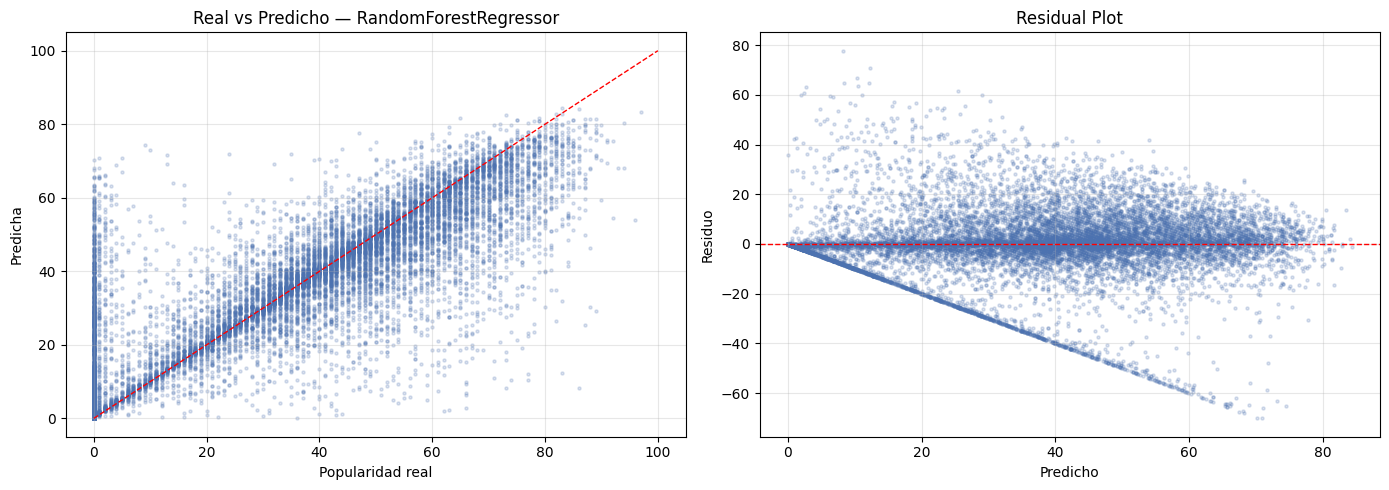

In [18]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor, BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ---- Preparación de datos para regresión ----
# Target: track_popularity continuo (0-100), ya disponible en el dataset procesado
y_reg = df["track_popularity"]
X_reg = df.drop(columns=["track_id", "track_popularity", "popular_high"])

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)
print(f"Regresión — X_train: {X_train_r.shape}, X_test: {X_test_r.shape}")
print(f"y_reg: mean={y_reg.mean():.2f}, std={y_reg.std():.2f}, min={y_reg.min()}, max={y_reg.max()}")

kf = KFold(n_splits=5, shuffle=True, random_state=42)

reg_model_configs = {
    "LinearRegression":     LinearRegression(),
    "Ridge":                Ridge(alpha=1.0),
    "RandomForestRegressor": RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    "GradientBoostingRegressor": GradientBoostingRegressor(n_estimators=200, random_state=42),
    "AdaBoostRegressor":    AdaBoostRegressor(n_estimators=100, random_state=42),
    "BaggingRegressor":     BaggingRegressor(
                                estimator=DecisionTreeRegressor(max_depth=8),
                                n_estimators=50, random_state=42, n_jobs=-1),
}

# ---- Validación cruzada (KFold 5) ----
print("\nValidación Cruzada (KFold 5) — Regresión:")
reg_cv_rows = []
for name, model in reg_model_configs.items():
    rmse_cv = -cross_val_score(model, X_reg, y_reg, cv=kf,
                               scoring="neg_root_mean_squared_error", n_jobs=-1)
    r2_cv = cross_val_score(model, X_reg, y_reg, cv=kf, scoring="r2", n_jobs=-1)
    reg_cv_rows.append({
        "model": name,
        "cv_rmse_mean": rmse_cv.mean(), "cv_rmse_std": rmse_cv.std(),
        "cv_r2_mean": r2_cv.mean(), "cv_r2_std": r2_cv.std(),
    })

reg_results_df = (pd.DataFrame(reg_cv_rows)
                  .sort_values("cv_rmse_mean").reset_index(drop=True))
print(reg_results_df.round(4).to_string(index=False))

# ---- Optimización de hiperparámetros (RandomizedSearchCV) ----
print("\nRandomizedSearchCV — Regresores (puede tardar varios minutos)...")
param_dist_rfr = {
    "n_estimators": randint(100, 400),
    "max_depth": [None, 10, 15, 20],
    "min_samples_split": randint(2, 15),
    "max_features": ["sqrt", "log2", 0.5],
}
param_dist_gbr = {
    "n_estimators": randint(100, 300),
    "learning_rate": uniform(0.01, 0.2),
    "max_depth": randint(3, 7),
    "subsample": uniform(0.6, 0.4),
}

rscv_rfr = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1), param_distributions=param_dist_rfr,
    n_iter=15, cv=kf, scoring="neg_root_mean_squared_error", random_state=42, n_jobs=-1
)
rscv_rfr.fit(X_train_r, y_train_r)
print(f"  RF Reg — mejores params: {rscv_rfr.best_params_}")
print(f"  RF Reg — mejor CV RMSE: {-rscv_rfr.best_score_:.4f}")

rscv_gbr = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=42), param_distributions=param_dist_gbr,
    n_iter=10, cv=kf, scoring="neg_root_mean_squared_error", random_state=42
)
rscv_gbr.fit(X_train_r, y_train_r)
print(f"  GB Reg — mejores params: {rscv_gbr.best_params_}")
print(f"  GB Reg — mejor CV RMSE: {-rscv_gbr.best_score_:.4f}")

# ---- Evaluación del mejor regresor en test set ----
best_reg_name = reg_results_df.iloc[0]["model"]
best_reg_estimator = rscv_rfr.best_estimator_ if "RandomForest" in best_reg_name else rscv_gbr.best_estimator_
best_reg_estimator.fit(X_train_r, y_train_r)
y_pred_r = best_reg_estimator.predict(X_test_r)

rmse_r = np.sqrt(mean_squared_error(y_test_r, y_pred_r))
mae_r = mean_absolute_error(y_test_r, y_pred_r)
r2_r = r2_score(y_test_r, y_pred_r)
print(f"\nMejor Regresor — test set: {best_reg_name}")
print(f"  RMSE: {rmse_r:.4f}")
print(f"  MAE:  {mae_r:.4f}")
print(f"  R²:   {r2_r:.4f}")

# Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_test_r, y_pred_r, alpha=0.2, s=5)
axes[0].plot([0, 100], [0, 100], "r--", lw=1)
axes[0].set_xlabel("Popularidad real"); axes[0].set_ylabel("Predicha")
axes[0].set_title(f"Real vs Predicho — {best_reg_name}"); axes[0].grid(alpha=0.3)

residuals_r = y_test_r - y_pred_r
axes[1].scatter(y_pred_r, residuals_r, alpha=0.2, s=5)
axes[1].axhline(0, color="r", linestyle="--", lw=1)
axes[1].set_xlabel("Predicho"); axes[1].set_ylabel("Residuo")
axes[1].set_title("Residual Plot"); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

### 2.5 Exportación de resultados y Resumen Ejecutivo — Regresión

In [19]:
reg_timestamp = pd.Timestamp.now().strftime("%Y%m%d_%H%M%S")

REG_REPORTS_DIR = BASE_DIR / "reports" / "03_modeling" / "reg_performance"
REG_REPORTS_DIR.mkdir(parents=True, exist_ok=True)

# Comparativa CV entre todos los regresores
reg_cv_path = REG_REPORTS_DIR / "reg_model_comparison.csv"
reg_cv_ts_path = REG_REPORTS_DIR / f"reg_model_comparison_{reg_timestamp}.csv"
reg_results_df.round(4).to_csv(reg_cv_path, index=False)
reg_results_df.round(4).to_csv(reg_cv_ts_path, index=False)

# Predicciones del mejor regresor
reg_pred_df = pd.DataFrame({
    "y_true": y_test_r.values,
    "y_pred": y_pred_r,
    "residual": (y_test_r - y_pred_r).values,
})
reg_pred_path = REG_REPORTS_DIR / "reg_best_model_predictions.csv"
reg_pred_ts_path = REG_REPORTS_DIR / f"reg_best_model_predictions_{reg_timestamp}.csv"
reg_pred_df.to_csv(reg_pred_path, index=False)
reg_pred_df.to_csv(reg_pred_ts_path, index=False)

print("Artefactos exportados — Módulo 2 Regresión:")
print(f"  • {reg_cv_path.name}")
print(f"  • {reg_pred_path.name}")

Artefactos exportados — Módulo 2 Regresión:
  • reg_model_comparison.csv
  • reg_best_model_predictions.csv


In [20]:
print("=" * 80)
print("RESUMEN EJECUTIVO — MÓDULO 2: REGRESIÓN SUPERVISADA")
print("=" * 80)

print(f"\n📦 DATASET:")
print(f"  • Shape: {X_reg.shape[0]:,} filas | Features: {X_reg.shape[1]} | Target: track_popularity (0-100)")
print(f"  • y_reg: mean={y_reg.mean():.2f}, std={y_reg.std():.2f}, min={int(y_reg.min())}, max={int(y_reg.max())}")
print(f"  • Split: train={X_train_r.shape[0]:,} / test={X_test_r.shape[0]:,} (80/20)")

print(f"\n🤖 MODELOS EVALUADOS (KFold 5):")
print(reg_results_df[["model","cv_rmse_mean","cv_rmse_std","cv_r2_mean","cv_r2_std"]].round(4).to_string(index=False))

reg_winner = reg_results_df.iloc[0]
rmse_test = np.sqrt(mean_squared_error(y_test_r, y_pred_r))
r2_test = r2_score(y_test_r, y_pred_r)
print(f"\n🏁 MEJOR MODELO: {reg_winner['model']}")
print(f"  • CV RMSE : {reg_winner['cv_rmse_mean']:.4f} ± {reg_winner['cv_rmse_std']:.4f}")
print(f"  • CV R²   : {reg_winner['cv_r2_mean']:.4f} ± {reg_winner['cv_r2_std']:.4f}")
print(f"  • RMSE (test) : {rmse_test:.4f}")
print(f"  • MAE  (test) : {mean_absolute_error(y_test_r, y_pred_r):.4f}")
print(f"  • R²   (test) : {r2_test:.4f}")
print("=" * 80)

RESUMEN EJECUTIVO — MÓDULO 2: REGRESIÓN SUPERVISADA

📦 DATASET:
  • Shape: 66,074 filas | Features: 10 | Target: track_popularity (0-100)
  • y_reg: mean=36.43, std=24.15, min=0, max=100
  • Split: train=52,859 / test=13,215 (80/20)

🤖 MODELOS EVALUADOS (KFold 5):
                    model  cv_rmse_mean  cv_rmse_std  cv_r2_mean  cv_r2_std
    RandomForestRegressor       14.1363       0.1529      0.6573     0.0068
GradientBoostingRegressor       14.3818       0.1514      0.6454     0.0048
         BaggingRegressor       14.5448       0.1420      0.6373     0.0048
                    Ridge       15.2905       0.1226      0.5992     0.0033
         LinearRegression       15.2905       0.1226      0.5992     0.0033
        AdaBoostRegressor       16.3233       0.1108      0.5432     0.0038

🏁 MEJOR MODELO: RandomForestRegressor
  • CV RMSE : 14.1363 ± 0.1529
  • CV R²   : 0.6573 ± 0.0068
  • RMSE (test) : 13.8166
  • MAE  (test) : 8.4720
  • R²   (test) : 0.6707


---

## MÓDULO 3: Aprendizaje No Supervisado

**Datos:** 10 features numéricas del dataset procesado (sin target)

**Etapas:**
1. Selección de k óptimo (elbow + silhouette)
2. Modelos de clustering: KMeans, AgglomerativeClustering, DBSCAN
3. Optimización: búsqueda de parámetros DBSCAN + selección de k
4. Ensamble: Consensus Clustering (20 runs de KMeans)
5. Métricas comparativas + enriquecimiento por cluster + visualización PCA
6. Exportación de resultados y Resumen Ejecutivo

Calculando k óptimo con elbow + silhouette (tarda ~1 min)...


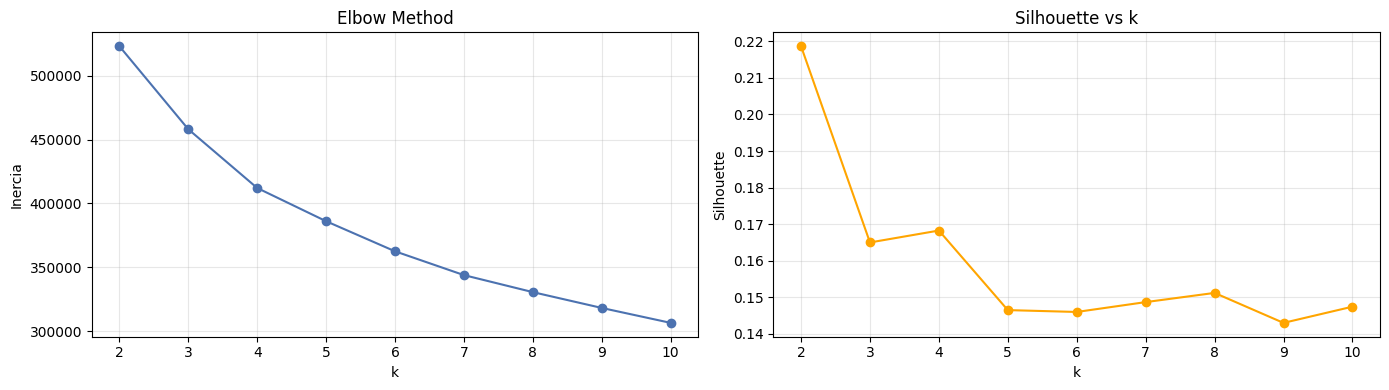

k óptimo: 2  (silhouette=0.2187)

Buscando parámetros DBSCAN...
Top 3 configuraciones DBSCAN:
 eps  min_samples  n_clusters  silhouette  noise_pct
 2.0           10           8      0.1718     0.0010
 2.0           50           5      0.1692     0.0036
 2.0           20           7      0.1669     0.0015

Consensus Clustering — 20 runs de KMeans sobre subsample de 5000...
Consensus Clustering completado.

Métricas no supervisadas:
                                     model  n_clusters  silhouette  davies_bouldin  calinski_harabasz
                                    KMeans           2      0.2191          1.8044         17352.4471
                   AgglomerativeClustering           2      0.2048          1.7822         12861.9789
                                    DBSCAN           8      0.1666          0.6500           709.9510
Consensus Clustering (Ensamble, subsample)           2      0.2212          1.7930          1270.3746

Enriquecimiento por cluster (KMeans):
             n  

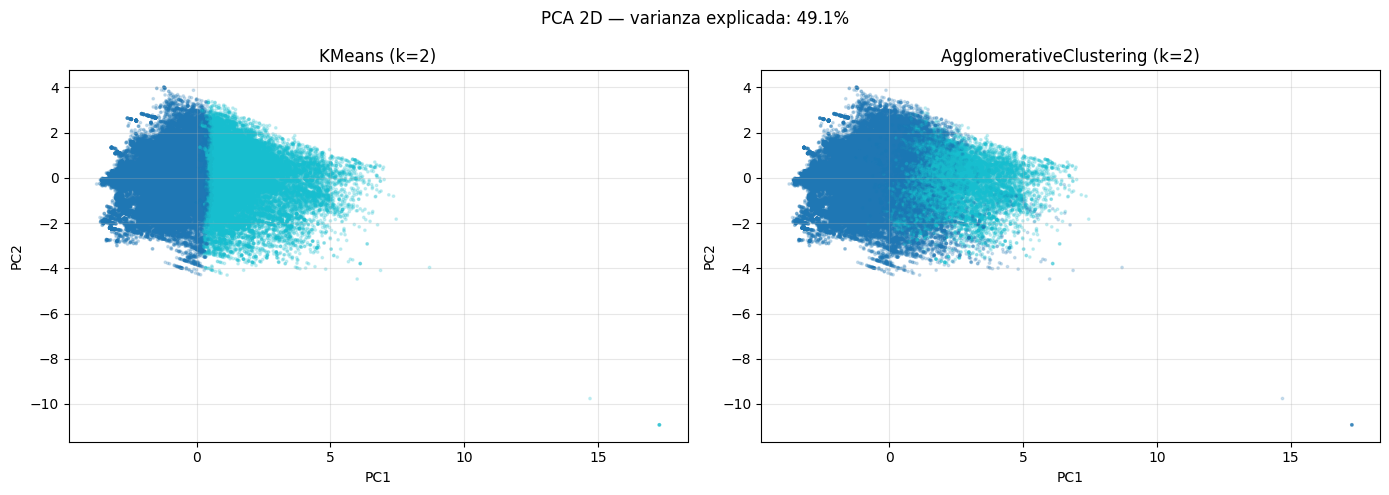

In [21]:
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# ---- Preparación de datos para clustering ----
FEATURE_COLS_CLUST = X.columns.tolist()
scaler_clust = StandardScaler()
X_clust = scaler_clust.fit_transform(df[FEATURE_COLS_CLUST].values)

# ---- 4.1 Selección de k: Elbow + Silhouette ----
print("Calculando k óptimo con elbow + silhouette (tarda ~1 min)...")
k_range = range(2, 11)
inertias, sil_scores = [], []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X_clust)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_clust, lbl, sample_size=5000, random_state=42))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(list(k_range), inertias, marker="o")
axes[0].set_title("Elbow Method"); axes[0].set_xlabel("k"); axes[0].set_ylabel("Inercia"); axes[0].grid(alpha=0.3)
axes[1].plot(list(k_range), sil_scores, marker="o", color="orange")
axes[1].set_title("Silhouette vs k"); axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette"); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

k_opt = int(list(k_range)[np.argmax(sil_scores)])
print(f"k óptimo: {k_opt}  (silhouette={max(sil_scores):.4f})")

# ---- 4.2 Modelos de clustering ----
km_opt = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
labels_km = km_opt.fit_predict(X_clust)

agg_opt = AgglomerativeClustering(n_clusters=k_opt)
labels_agg = agg_opt.fit_predict(X_clust)

# DBSCAN: búsqueda de parámetros sobre grilla reducida
print("\nBuscando parámetros DBSCAN...")
dbscan_grid = []
for eps in [0.5, 0.8, 1.0, 1.2, 1.5, 2.0]:
    for min_s in [5, 10, 20, 50]:
        lbl_db = DBSCAN(eps=eps, min_samples=min_s).fit_predict(X_clust)
        n_cl = len(set(lbl_db)) - (1 if -1 in lbl_db else 0)
        mask = lbl_db != -1
        if 2 <= n_cl <= 15 and mask.sum() > 100:
            sil_db = silhouette_score(X_clust[mask], lbl_db[mask], sample_size=min(5000, mask.sum()), random_state=42)
            dbscan_grid.append({"eps": eps, "min_samples": min_s, "n_clusters": n_cl,
                                "silhouette": sil_db, "noise_pct": (~mask).mean()})

if dbscan_grid:
    dbscan_grid_df = pd.DataFrame(dbscan_grid).sort_values("silhouette", ascending=False)
    print("Top 3 configuraciones DBSCAN:"); print(dbscan_grid_df.head(3).round(4).to_string(index=False))
    best_db = dbscan_grid_df.iloc[0]
    db_opt = DBSCAN(eps=best_db["eps"], min_samples=int(best_db["min_samples"]))
else:
    print("DBSCAN: sin config válida, usando defaults.")
    db_opt = DBSCAN(eps=1.0, min_samples=10)
labels_db = db_opt.fit_predict(X_clust)

# ---- 4.3 Ensamble: Consensus Clustering (subsample 5000) ----
print("\nConsensus Clustering — 20 runs de KMeans sobre subsample de 5000...")
np.random.seed(42)
sub_idx = np.random.choice(X_clust.shape[0], size=min(5000, X_clust.shape[0]), replace=False)
X_sub = X_clust[sub_idx]
n_sub = X_sub.shape[0]

co_assoc = np.zeros((n_sub, n_sub), dtype=np.float32)
for seed in range(20):
    km_r = KMeans(n_clusters=k_opt, random_state=seed, n_init=5)
    lbl_r = km_r.fit_predict(X_sub)
    co_assoc += (lbl_r[:, None] == lbl_r[None, :]).astype(np.float32)
co_assoc /= 20

agg_cons = AgglomerativeClustering(n_clusters=k_opt, metric="precomputed", linkage="average")
labels_cons_sub = agg_cons.fit_predict((1 - co_assoc).astype(np.float64))
print("Consensus Clustering completado.")

# ---- 4.4 Métricas comparativas ----
def unsup_metrics_row(name, labels, X_sc):
    mask = labels != -1
    n_cl = len(set(labels[mask]))
    if n_cl < 2:
        return {"model": name, "n_clusters": n_cl, "silhouette": np.nan,
                "davies_bouldin": np.nan, "calinski_harabasz": np.nan}
    rng = np.random.default_rng(42)
    s_idx = rng.choice(np.where(mask)[0], size=min(5000, mask.sum()), replace=False)
    return {
        "model": name,
        "n_clusters": n_cl,
        "silhouette": silhouette_score(X_sc[s_idx], labels[s_idx]),
        "davies_bouldin": davies_bouldin_score(X_sc[mask], labels[mask]),
        "calinski_harabasz": calinski_harabasz_score(X_sc[mask], labels[mask]),
    }

unsup_metrics_df = pd.DataFrame([
    unsup_metrics_row("KMeans", labels_km, X_clust),
    unsup_metrics_row("AgglomerativeClustering", labels_agg, X_clust),
    unsup_metrics_row("DBSCAN", labels_db, X_clust),
    unsup_metrics_row("Consensus Clustering (Ensamble, subsample)", labels_cons_sub, X_sub),
]).round(4)
print("\nMétricas no supervisadas:"); print(unsup_metrics_df.to_string(index=False))

# Enriquecimiento por cluster (KMeans sobre dataset completo)
df_enrich = df[["popular_high", "track_popularity"]].copy()
df_enrich["cluster"] = labels_km
enrich = df_enrich.groupby("cluster").agg(
    n=("popular_high", "count"),
    pct_popular=("popular_high", "mean"),
    avg_track_popularity=("track_popularity", "mean"),
).round(3)
print("\nEnriquecimiento por cluster (KMeans):"); print(enrich.to_string())

# ---- 4.5 Visualización PCA 2D ----
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_clust)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, lbl, title in [
    (axes[0], labels_km, f"KMeans (k={k_opt})"),
    (axes[1], labels_agg, f"AgglomerativeClustering (k={k_opt})"),
]:
    ax.scatter(X_pca[:, 0], X_pca[:, 1], c=lbl, cmap="tab10", alpha=0.2, s=3)
    ax.set_title(title); ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.grid(alpha=0.3)
plt.suptitle(f"PCA 2D — varianza explicada: {pca.explained_variance_ratio_.sum():.1%}")
plt.tight_layout(); plt.show()

### 3.6 Exportación de resultados y Resumen Ejecutivo — No Supervisado

In [22]:
unsup_timestamp = pd.Timestamp.now().strftime("%Y%m%d_%H%M%S")

UNSUP_REPORTS_DIR = BASE_DIR / "reports" / "03_modeling" / "unsup_performance"
UNSUP_REPORTS_DIR.mkdir(parents=True, exist_ok=True)

# Métricas comparativas entre algoritmos
unsup_metrics_path = UNSUP_REPORTS_DIR / "unsup_model_comparison.csv"
unsup_metrics_ts_path = UNSUP_REPORTS_DIR / f"unsup_model_comparison_{unsup_timestamp}.csv"
unsup_metrics_df.to_csv(unsup_metrics_path, index=False)
unsup_metrics_df.to_csv(unsup_metrics_ts_path, index=False)

# Enriquecimiento por cluster (KMeans)
enrich_path = UNSUP_REPORTS_DIR / "unsup_cluster_enrichment.csv"
enrich_ts_path = UNSUP_REPORTS_DIR / f"unsup_cluster_enrichment_{unsup_timestamp}.csv"
enrich.to_csv(enrich_path)
enrich.to_csv(enrich_ts_path)

# Labels KMeans para trazabilidad
labels_df = df[["track_id"]].copy()
labels_df["cluster_kmeans"] = labels_km
labels_path = UNSUP_REPORTS_DIR / "unsup_kmeans_labels.csv"
labels_ts_path = UNSUP_REPORTS_DIR / f"unsup_kmeans_labels_{unsup_timestamp}.csv"
labels_df.to_csv(labels_path, index=False)
labels_df.to_csv(labels_ts_path, index=False)

print("Artefactos exportados — Módulo 3 No Supervisado:")
print(f"  • {unsup_metrics_path.name}")
print(f"  • {enrich_path.name}")
print(f"  • {labels_path.name}")

Artefactos exportados — Módulo 3 No Supervisado:
  • unsup_model_comparison.csv
  • unsup_cluster_enrichment.csv
  • unsup_kmeans_labels.csv


In [23]:
print("=" * 80)
print("RESUMEN EJECUTIVO — MÓDULO 3: APRENDIZAJE NO SUPERVISADO")
print("=" * 80)

print(f"\n📦 DATOS:")
print(f"  • Shape: {X_clust.shape[0]:,} filas | Features: {X_clust.shape[1]} (estandarizadas)")
print(f"  • k óptimo seleccionado: {k_opt}  (por silhouette máximo)")

print(f"\n🤖 MODELOS EVALUADOS:")
print(unsup_metrics_df.to_string(index=False))

unsup_full_m = unsup_metrics_df[~unsup_metrics_df["model"].str.contains("Ensamble")].dropna(subset=["silhouette"])
unsup_winner = unsup_full_m.loc[unsup_full_m["silhouette"].idxmax()]
print(f"\n🏁 MEJOR MODELO (por silhouette): {unsup_winner['model']}")
print(f"  • Silhouette         : {unsup_winner['silhouette']:.4f}")
print(f"  • Davies-Bouldin     : {unsup_winner['davies_bouldin']:.4f}  (menor = mejor)")
print(f"  • Calinski-Harabasz  : {unsup_winner['calinski_harabasz']:.1f}  (mayor = mejor)")
print(f"  • n_clusters         : {int(unsup_winner['n_clusters'])}")

print(f"\n📊 ENRIQUECIMIENTO POR CLUSTER (KMeans):")
print(enrich.to_string())
print("=" * 80)

RESUMEN EJECUTIVO — MÓDULO 3: APRENDIZAJE NO SUPERVISADO

📦 DATOS:
  • Shape: 66,074 filas | Features: 10 (estandarizadas)
  • k óptimo seleccionado: 2  (por silhouette máximo)

🤖 MODELOS EVALUADOS:
                                     model  n_clusters  silhouette  davies_bouldin  calinski_harabasz
                                    KMeans           2      0.2191          1.8044         17352.4471
                   AgglomerativeClustering           2      0.2048          1.7822         12861.9789
                                    DBSCAN           8      0.1666          0.6500           709.9510
Consensus Clustering (Ensamble, subsample)           2      0.2212          1.7930          1270.3746

🏁 MEJOR MODELO (por silhouette): KMeans
  • Silhouette         : 0.2191
  • Davies-Bouldin     : 1.8044  (menor = mejor)
  • Calinski-Harabasz  : 17352.4  (mayor = mejor)
  • n_clusters         : 2

📊 ENRIQUECIMIENTO POR CLUSTER (KMeans):
             n  pct_popular  avg_track_popularity
c

---

## Conclusión Final — Comparación entre Paradigmas

Tabla comparativa de los mejores modelos por paradigma.
Las conclusiones y el análisis narrativo se documentan en `reports/03_modeling/ANALYSIS_YYYYMMDD.md`.

In [25]:
clf_best = comparison_all_clf.iloc[0]
reg_best = reg_results_df.iloc[0]
unsup_full_c = unsup_metrics_df[~unsup_metrics_df["model"].str.contains("Ensamble")].dropna(subset=["silhouette"])
unsup_best = unsup_full_c.loc[unsup_full_c["silhouette"].idxmax()]

summary_final = pd.DataFrame([
    {
        "Paradigma":          "Clasificación Supervisada",
        "Mejor Modelo":       clf_best["model"],
        "Métrica Principal":  "ROC-AUC",
        "Valor":              f"{clf_best['roc_auc']:.4f}",
        "Métrica Secundaria": f"F1={clf_best['f1']:.4f}",
    },
    {
        "Paradigma":          "Regresión Supervisada",
        "Mejor Modelo":       reg_best["model"],
        "Métrica Principal":  "RMSE (CV)",
        "Valor":              f"{reg_best['cv_rmse_mean']:.3f}",
        "Métrica Secundaria": f"R²={reg_best['cv_r2_mean']:.4f}",
    },
    {
        "Paradigma":          "Aprendizaje No Supervisado",
        "Mejor Modelo":       unsup_best["model"],
        "Métrica Principal":  "Silhouette",
        "Valor":              f"{unsup_best['silhouette']:.4f}",
        "Métrica Secundaria": f"k={int(unsup_best['n_clusters'])}",
    },
])

print("=" * 80)
print("TABLA COMPARATIVA — LOS TRES PARADIGMAS")
print("=" * 80)
print(summary_final.to_string(index=False))
print("=" * 80)


TABLA COMPARATIVA — LOS TRES PARADIGMAS
                 Paradigma           Mejor Modelo Métrica Principal  Valor Métrica Secundaria
 Clasificación Supervisada GradientBoosting_Tuned           ROC-AUC 0.9518          F1=0.8083
     Regresión Supervisada  RandomForestRegressor         RMSE (CV) 14.136          R²=0.6573
Aprendizaje No Supervisado                 KMeans        Silhouette 0.2191                k=2
